In [21]:

!pip install pandas numpy scikit-learn scikit-optimize matplotlib seaborn openpyxl

In [22]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor

from skopt import gp_minimize
from skopt.space import Real, Integer

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

In [23]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

data = pd.read_excel(filename)

print("Dataset Loaded\n")

print(data.head())
print("\nColumns:")
print(data.columns)
print("\nShape:",data.shape)

Saving BENZENETOLUENEDATA.xlsx to BENZENETOLUENEDATA (2).xlsx
Dataset Loaded

   Reflux Ratio  Number of Stages  \
0           2.0           10.0000   
1           2.0           11.1111   
2           2.0           12.2222   
3           2.0           13.3333   
4           2.0           14.4444   

   DISTILLATE - Molar Fraction (Mixture) / Benzene ()  \
0                                           0.993366    
1                                           0.652720    
2                                           0.774254    
3                                           0.858671    
4                                           0.912188    

   DCOL-1 - Reboiler Duty (kW)  DCOL-1 - Condenser Duty (kW)  
0                     -1929.40                       1887.15  
1                     -2070.72                       2041.28  
2                     -1720.73                       1686.29  
3                     -1534.63                       1497.01  
4                     -1433.79           

In [24]:
X = data[["Reflux Ratio","Number of Stages"]]

# Targets
y_purity = data["DISTILLATE - Molar Fraction (Mixture) / Benzene ()"]

# Energy consumption (absolute value)
data["Energy"] = abs(data["DCOL-1 - Reboiler Duty (kW)"])

y_energy = data["Energy"]

print("\nDataset ready for training")


Dataset ready for training


In [25]:
from sklearn.ensemble import RandomForestRegressor


purity_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

purity_model.fit(X, y_purity)



energy_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

energy_model.fit(X, y_energy)


print("Models trained successfully")

Models trained successfully


In [26]:
def objective(params):

    reflux, stages = params

    stages = int(stages)   # enforcing integer stages as decimal stages are not feasible

    purity = purity_model.predict([[reflux, stages]])[0]
    energy = energy_model.predict([[reflux, stages]])[0]

    score = purity - 0.0001 * energy

    return -score

In [27]:
from skopt import gp_minimize
from skopt.space import Real, Integer


search_space = [

    Real(2,5,name='reflux'),
    Integer(10,25,name='stages')

]


result = gp_minimize(

    objective,
    search_space,
    n_calls=40,
    random_state=42

)


opt_reflux = result.x[0]
opt_stages = result.x[1]

opt_purity = purity_model.predict([[opt_reflux,opt_stages]])[0]
opt_energy = energy_model.predict([[opt_reflux,opt_stages]])[0]


print("\nOptimal Design Found\n")

print("Optimal Reflux Ratio:", opt_reflux)
print("Optimal Stages:", opt_stages)
print("Predicted Purity:", opt_purity)
print("Predicted Energy:", opt_energy)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/


Optimal Design Found

Optimal Reflux Ratio: 2.0
Optimal Stages: 25
Predicted Purity: 0.97635651
Predicted Energy: 1329.2521000000022


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [28]:
import numpy as np

reflux_vals = np.linspace(2,5,30)
stage_vals = np.arange(10,26)

R,S = np.meshgrid(reflux_vals,stage_vals)

purity_surface = np.zeros_like(R)
energy_surface = np.zeros_like(R)

for i in range(R.shape[0]):

    for j in range(R.shape[1]):

        purity_surface[i,j] = purity_model.predict([[R[i,j],S[i,j]]])[0]
        energy_surface[i,j] = energy_model.predict([[R[i,j],S[i,j]]])[0]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/

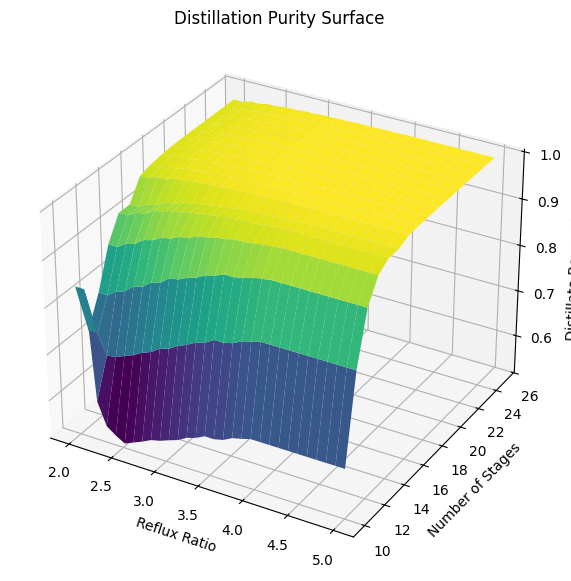

In [29]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111,projection='3d')

ax.plot_surface(R,S,purity_surface,cmap="viridis")

ax.set_xlabel("Reflux Ratio")
ax.set_ylabel("Number of Stages")
ax.set_zlabel("Distillate Benzene Purity")

plt.title("Distillation Purity Surface")

plt.show()

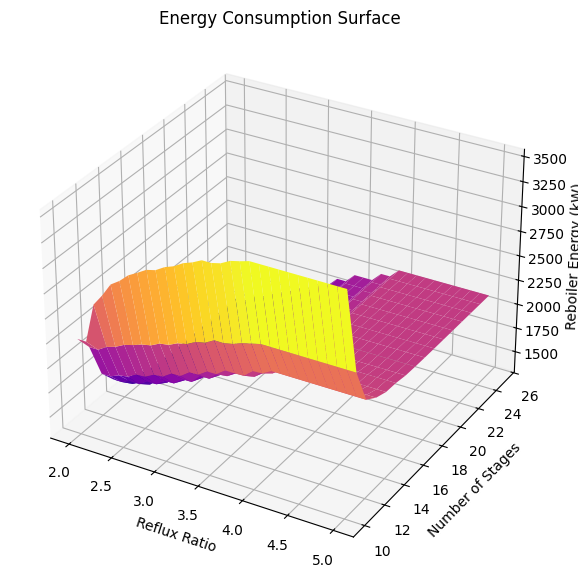

In [30]:
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111,projection='3d')

ax.plot_surface(R,S,energy_surface,cmap="plasma")

ax.set_xlabel("Reflux Ratio")
ax.set_ylabel("Number of Stages")
ax.set_zlabel("Reboiler Energy (kW)")

plt.title("Energy Consumption Surface")

plt.show()

In [31]:
grid = pd.DataFrame({

    "Reflux": R.flatten(),
    "Stages": S.flatten(),
    "Predicted_Purity": purity_surface.flatten(),
    "Predicted_Energy": energy_surface.flatten()

})

grid.to_csv("optimization_surface.csv",index=False)

print("Surface data exported")

Surface data exported


In [32]:
import os
from google.colab import files

# Creating results folder
os.makedirs("results", exist_ok=True)




print("\n==============================")
print(" AI OPTIMIZATION RESULTS")
print("==============================\n")

print(f"Optimal Reflux Ratio  : {opt_reflux:.3f}")
print(f"Optimal Stages        : {opt_stages}")
print(f"Predicted Purity      : {opt_purity:.4f}")
print(f"Predicted Energy (kW) : {opt_energy:.2f}")





fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(R,S,purity_surface,cmap="viridis")

ax.set_xlabel("Reflux Ratio")
ax.set_ylabel("Number of Stages")
ax.set_zlabel("Distillate Benzene Purity")

plt.title("Distillation Purity Surface")

purity_path = "results/purity_surface.png"
plt.savefig(purity_path, dpi=300)
plt.close()





fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(R,S,energy_surface,cmap="plasma")

ax.set_xlabel("Reflux Ratio")
ax.set_ylabel("Number of Stages")
ax.set_zlabel("Energy Consumption (kW)")

plt.title("Energy Consumption Surface")

energy_path = "results/energy_surface.png"
plt.savefig(energy_path, dpi=300)
plt.close()





result_df = pd.DataFrame({

    "Optimal_Reflux_Ratio":[opt_reflux],
    "Optimal_Stages":[opt_stages],
    "Predicted_Purity":[opt_purity],
    "Predicted_Energy_kW":[opt_energy]

})

result_csv = "results/optimal_conditions.csv"

result_df.to_csv(result_csv,index=False)




surface_data = pd.DataFrame({

    "Reflux_Ratio": R.flatten(),
    "Stages": S.flatten(),
    "Predicted_Purity": purity_surface.flatten(),
    "Predicted_Energy": energy_surface.flatten()

})

surface_csv = "results/optimization_surface.csv"

surface_data.to_csv(surface_csv,index=False)



print("\nFiles saved:")
print(" - purity_surface.png")
print(" - energy_surface.png")
print(" - optimal_conditions.csv")
print(" - optimization_surface.csv")




# Download Files


files.download(purity_path)
files.download(energy_path)
files.download(result_csv)
files.download(surface_csv)


 AI OPTIMIZATION RESULTS

Optimal Reflux Ratio  : 2.000
Optimal Stages        : 25
Predicted Purity      : 0.9764
Predicted Energy (kW) : 1329.25

Files saved:
 - purity_surface.png
 - energy_surface.png
 - optimal_conditions.csv
 - optimization_surface.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>